In [11]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [12]:
import pandas as pd 

sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_3892\118592328.py:3: DtypeWarning: Columns (6,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_3892\118592328.py:7: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_3892\118592328.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_3892\118592328.py:9: DtypeWarning: Columns (7,8,9,12,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")


In [15]:
import importlib
import src.feature.feature
import src.feature.merge

importlib.reload(src.feature.feature)
importlib.reload(src.feature.merge)

<module 'src.feature.merge' from 'e:\\TKsolution\\warehouse AI\\src\\feature\\merge.py'>

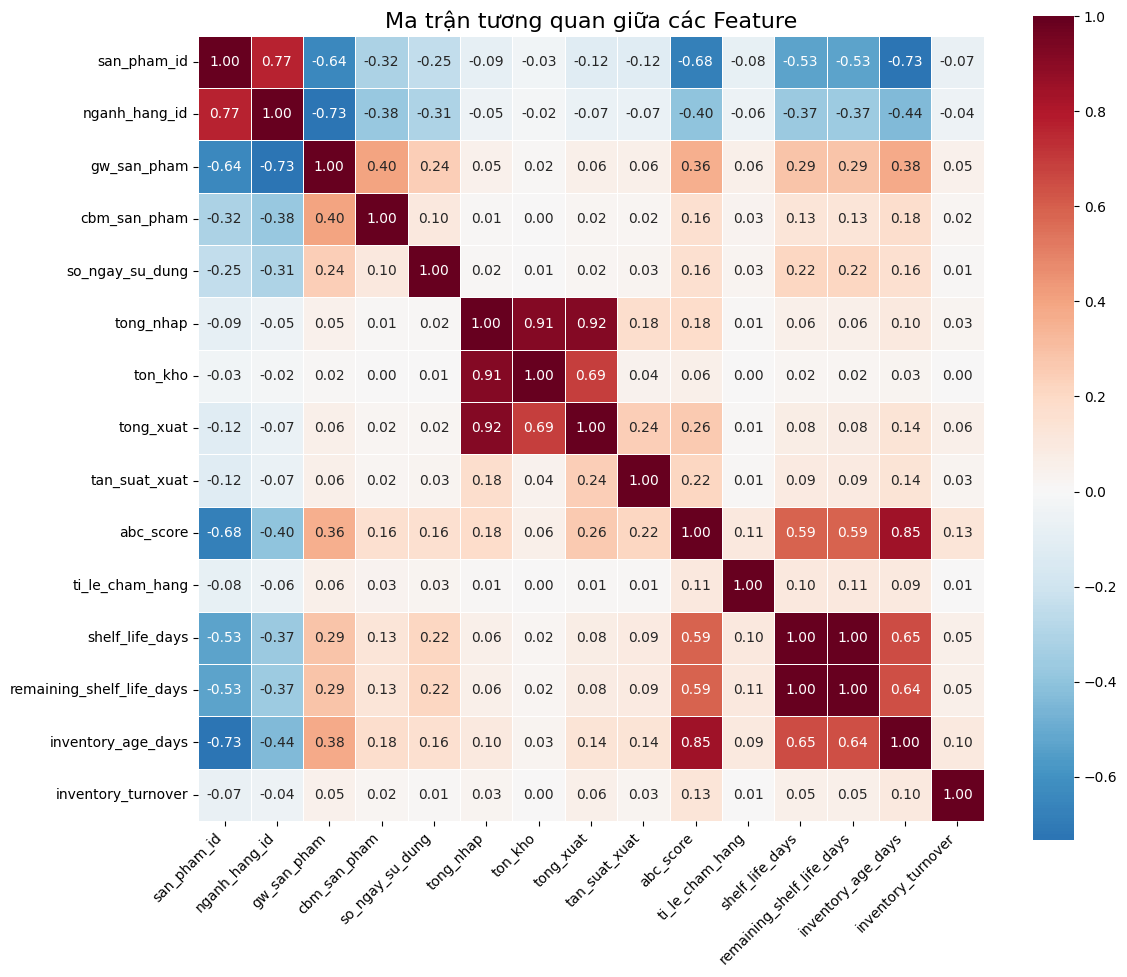

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chỉ lấy các cột số
corr = feature_table.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,          # Hiển thị hệ số tương quan
    fmt=".2f",
    cmap="RdBu_r",       # Đỏ: tương quan dương, Xanh: tương quan âm
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Ma trận tương quan giữa các Feature", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
from src.feature.merge import build_feature_table

feature_table = build_feature_table(
    sanpham,
    tonkho,
    nhapkho,
    xuatkho,
    cham
)

In [21]:
# from pathlib import Path

# output_dir = Path("../data/process")
# output_dir.mkdir(parents=True, exist_ok=True)

# feature_table.to_csv(
#     output_dir / "feature_new.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Đã lưu:", output_dir / "feature_new.csv")

Đã lưu: ..\data\process\feature_new.csv


## Merge data để train 

In [22]:
import pandas as pd

feature_new = pd.read_csv("../data/process/feature_new.csv")
rules_train = pd.read_csv("../data/process/rules_train.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_3892\236391906.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  feature_new = pd.read_csv("../data/process/feature_new.csv")


In [23]:
dataset = feature_new.merge(
    rules_train,
    on="san_pham_id",
    how="inner"
)

In [24]:
warehouse_map = {
    12473657: "1",
    12630830: "3",
    12630825: "2"
}

dataset["warehouse_id"] = (
    dataset["loai_kho"]
    .map(warehouse_map)
)

In [30]:
abc_map = {
    "A":3,
    "B":2,
    "C":1
}

dataset["abc_score"] = (
    dataset["abc_class"]
    .map(abc_map)
)

In [31]:
dataset.head(20)

,san_pham_id,nganh_hang_id,gw_san_pham,cbm_san_pham,so_ngay_su_dung,tong_nhap,ton_kho,tong_xuat,tan_suat_xuat,abc_class,...,remaining_shelf_life_days,inventory_age_days,inventory_turnover,loai_kho,so_day,day_chinh,ty_le,so_tang,tang_chinh,warehouse_id
0,20003159.0,12501018.0,5.8,13700.500,0.0,40.0,0.0,56.0,7.0,C,...,0.000000,376.000000,0.000000,12473657,4,12473743,25.00,3,3,1
1,12504099.0,12501018.0,5.8,14256.000,0.0,200.0,0.0,256.0,21.0,C,...,0.000000,351.333333,0.000000,12473657,4,12473743,33.33,4,0,1
2,12504065.0,12501018.0,9.0,19600.000,1096.0,1308.0,48.0,1314.0,94.0,C,...,1026.055556,234.100000,27.375000,12473657,7,12473743,37.50,6,0,1
3,12504075.0,12501018.0,9.0,18483.750,1096.0,924.0,210.0,372.0,34.0,C,...,1009.750000,347.200000,1.771429,12473657,8,12473743,23.53,8,5,1
4,12505475.0,12501018.0,10.5,28927.500,1096.0,16380.0,1656.0,10764.0,269.0,B,...,1094.862069,232.823529,6.500000,12473657,13,12473779,22.73,10,5,1
5,12505475.0,12501018.0,10.5,28927.500,1096.0,16380.0,1656.0,10764.0,269.0,B,...,1094.862069,232.823529,6.500000,12630830,1,49647766,100.00,1,0,3
6,12505495.0,12501018.0,8.0,22500.000,1096.0,1728.0,360.0,720.0,20.0,C,...,1072.727273,150.727273,2.000000,12473657,6,12473743,45.45,6,0,1
7,12505495.0,12501018.0,8.0,22500.000,1096.0,1728.0,360.0,720.0,20.0,C,...,1072.727273,150.727273,2.000000,12630830,1,49647766,100.00,1,0,3
8,12501115.0,12501020.0,12.0,33214.000,730.0,2772.0,174.0,1860.0,156.0,C,...,689.214286,256.285714,10.689655,12473657,7,12473765,45.45,7,0,1
9,12503889.0,12501016.0,3.8,37740.000,0.0,6756.0,684.0,4832.0,281.0,B,...,1684.000000,289.285714,7.064327,12473657,8,12473791,30.00,8,0,1


In [32]:
from pathlib import Path

output_dir = Path("../data/process")
output_dir.mkdir(parents=True, exist_ok=True)

dataset.to_csv(
    output_dir / "dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:", output_dir / "fdataset.csv")

Đã lưu: ..\data\process\fdataset.csv


In [36]:
print(feature_new["san_pham_id"].nunique())
print(rules_train["san_pham_id"].nunique())
tonkho["san_pham_id"].nunique()

348316
8339


8339

In [37]:
print(tonkho["san_pham_id"].nunique())

8339
